In [1]:
import pandas as pd
import numpy as np
import datetime
from scorepi import *
from epiweeks import Week
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import defaultdict
import seaborn as sns
import datetime
from datetime import datetime
from datetime import timedelta
from pathlib import Path
import matplotlib as mpl
import random
from numba import njit
from scipy.stats import linregress
import scipy.stats as stats
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

import warnings
warnings.filterwarnings('ignore')

In [13]:
from numba import njit
@njit
def energyscore(X,y):
    # X is matrix of trajectories, y is observations
    ES = 0
    N = X.shape[0]
    for i in range(N):
        ES += np.sqrt(np.sum((X[i]-y)**2))/N
    for i in range(N):
        for j in range(N):
            ES -= np.sqrt(np.sum((X[i]-X[j])**2))/(2*N**2)
    return ES


In [14]:
@njit
def normalized_energyscore(X,y):
    # X is matrix of trajectories, y is observations
    ES = 0
    N = X.shape[0]
    for i in range(N):
        ES += np.sqrt(np.sum(((X[i]-y))**2))/N
    for i in range(N):
        for j in range(N):
            ES -= np.sqrt(np.sum(((X[i]-X[j]))**2))/(2*N**2)
    return ES/sum(y)

In [15]:
import matplotlib.dates as mdates
def set_date_axis_fmt(ax):
    # Set the locator
    locator = mdates.MonthLocator()  # every month
    # Specify the format
    fmt = mdates.DateFormatter('%b %y')

    X = ax.xaxis
    X.set_major_locator(locator)
    # Specify formatter
    X.set_major_formatter(fmt)
    
    
def pull_surveillance_data():
    #flu surveillance data
    
    url = f"https://raw.githubusercontent.com/CDCgov/covid19-forecast-hub/refs/heads/main/target-data/covid-hospital-admissions.csv"
    return pd.read_csv(url, dtype={'location':str})



def pull_covid_scenario_modeling_hub_predictions(model,dates):
    """pull_scenario_modeling_hub_predictions. Load predictions of the model saved by the scenario modeling
    hub.

    Parameters
    ----------
    model : str
        Model name on thhe
    dates : list or string
        List of potential dates in the iso format, e.g., 'yyyy-mm-dd', for the submission.
    """
    predictions = None
    if isinstance(dates,str):
        dates = [dates]
    for date in dates:
        url = f"https://raw.githubusercontent.com/midas-network/covid19-scenario-modeling-hub/master/model-output/{model}/{date}-{model}"
        for ext in [".gz.parquet", ".parquet"]:
                try:
                    predictions = pd.read_parquet(url+ext)
                    
                except:
                    pass

    if predictions is None:
        print(f"Data for model {model} and date {dates} unavailable")
    return predictions



In [16]:
def format_observations(location, start_week = pd.to_datetime('2023-09-09') ):
    observations = pd.read_parquet(f"../fludat/truth_{'inc' if incidence else 'cum'}_{target_obs}.pq")
    observations['date'] = pd.to_datetime(observations['date'])

    #filter start - end week
    max_date = pd.to_datetime(observations.date.max())
    observations = observations[(observations['date'] >= start_week) & \
                                (observations['date'] <= max_date)]

    #filter location
    observations = observations[observations['location'] == location]

    #aggregate to weekly
    observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

    #transform to Observation object
    observations = Observations(observations)

    return observations

Pull surveillance data

In [26]:
target = 'hospitalization'
incidence=True
observations = pull_surveillance_data()
observations


,state,target_end_date,value,location
0,AK,2024-11-09,14,02
1,AK,2024-11-16,11,02
2,AK,2024-11-23,10,02
3,AK,2024-11-30,6,02
4,AK,2024-12-07,18,02
...,...,...,...,...
4076,WY,2026-03-28,17,56
4077,WY,2026-04-04,10,56
4078,WY,2026-04-11,1,56
4079,WY,2026-04-18,13,56


In [7]:
observations.target.unique()

array(['inc death', 'inc hosp'], dtype=object)

Pull COVID-19 Round 19 Scenario Modeling Hub data for all models

In [42]:
models = ['CFA-Scenarios', 'JHU_UNC-flepiMoP', 'LEMMA-EnsembleDTWS', 'MOBS_NEU-GLEAM_COVID', 'PSI-M_CoV_2025',
            'UIUC-IMMCYC', 'UNCC-Hierbin', 'UT-ImmunoSEIRS', 'UVA-adaptive']
dates = ['2025-04-27']
rd = 4

for model in models:
    predictions = pull_covid_scenario_modeling_hub_predictions(model,dates)
    predictions['Model'] = model
    
    predictions = predictions[predictions['target'] =='inc hosp']


    numweeks = list(predictions.horizon.unique())

    start_date = list(predictions.origin_date.unique())[0]
    date_1 = pd.to_datetime(start_date)

    alldates = []
    for wk in numweeks:
        if wk==1:
            d = date_1 + timedelta(days=6*int(wk))
        else:
            d = date_1 + timedelta(days=6) + timedelta(weeks=int(wk-1))

        alldates.append(d)

    dfdates = pd.DataFrame({'horizon':numweeks, 'target_end_date':alldates})


    df = predictions.merge(dfdates, how='inner', on='horizon')


    df.to_parquet(f'../coviddat/{model}_rd{rd}_hosp.pq', index=False)
    
    

In [43]:
# save into one dataframe

In [18]:
models = ['CFA-Scenarios', 'JHU_UNC-flepiMoP', 'LEMMA-EnsembleDTWS', 'MOBS_NEU-GLEAM_COVID', 'PSI-M_CoV_2025',
            'UIUC-IMMCYC', 'UNCC-Hierbin', 'UT-ImmunoSEIRS', 'UVA-adaptive']
dates = '2025-04-27'
rd = 19


In [19]:
predictionsall = pd.DataFrame()
for model in models:
    df = pd.read_parquet(f'../coviddat/{model}_rd4_hosp.pq')
    print(model, len(df.location.unique())) 
    
    predictionsall = pd.concat([predictionsall, df])

CFA-Scenarios 51
JHU_UNC-flepiMoP 52
LEMMA-EnsembleDTWS 52
MOBS_NEU-GLEAM_COVID 52
PSI-M_CoV_2025 52
UIUC-IMMCYC 52
UNCC-Hierbin 52
UT-ImmunoSEIRS 51
UVA-adaptive 52


In [20]:
predictionsall

,origin_date,scenario_id,location,target,horizon,age_group,output_type,output_type_id,run_grouping,stochastic_run,value,Model,target_end_date
0,2025-04-27,A-2025-04-01,02,inc hosp,1.0,0-130,sample,NaN,1.0,1.0,17.0,CFA-Scenarios,2025-05-03
1,2025-04-27,A-2025-04-01,02,inc hosp,1.0,0-64,sample,NaN,1.0,1.0,4.0,CFA-Scenarios,2025-05-03
2,2025-04-27,A-2025-04-01,02,inc hosp,1.0,65-130,sample,NaN,1.0,1.0,13.0,CFA-Scenarios,2025-05-03
3,2025-04-27,A-2025-04-01,02,inc hosp,1.0,0-130,sample,NaN,1.0,2.0,14.0,CFA-Scenarios,2025-05-03
4,2025-04-27,A-2025-04-01,02,inc hosp,1.0,0-64,sample,NaN,1.0,2.0,8.0,CFA-Scenarios,2025-05-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4988875,2025-04-27,E-2025-04-01,US,inc hosp,52.0,0-130,sample,NaN,96.0,1.0,6628.0,UVA-adaptive,2026-04-25
4988876,2025-04-27,E-2025-04-01,US,inc hosp,52.0,0-130,sample,NaN,97.0,1.0,6942.4,UVA-adaptive,2026-04-25
4988877,2025-04-27,E-2025-04-01,US,inc hosp,52.0,0-130,sample,NaN,98.0,1.0,6897.6,UVA-adaptive,2026-04-25
4988878,2025-04-27,E-2025-04-01,US,inc hosp,52.0,0-130,sample,NaN,99.0,1.0,6467.2,UVA-adaptive,2026-04-25


In [29]:
# filter by trajectories and only look at age group with all ages combined
predictions_traj = predictionsall[(predictionsall.output_type == 'sample') & \
                                   (predictionsall.age_group == '0-130')]
# filter by dates with data
predictions_traj = predictions_traj[predictions_traj.target_end_date <= pd.to_datetime(observations.target_end_date.max())]

In [32]:
predictionsall.target_end_date.max()

Timestamp('2026-04-25 00:00:00')

# Calculate scores

Calculate energy score for each model, scenario, and location

In [33]:
locations = pd.read_csv('../fludat/locations.csv',dtype={'location':str})
target_obs = 'hospitalization'
observations = pull_surveillance_data().rename(columns={'target_end_date':'date'})
            
start_week = pd.to_datetime('2025-05-03')
max_date = pd.to_datetime(observations.date.max())


energyscoresdf = pd.DataFrame()


predictions_traj['target_end_date'] = pd.to_datetime(predictions_traj['target_end_date'])

for model in predictions_traj.Model.unique():
    for loc in predictions_traj.location.unique():
        
        if loc in ['60','66','69', '72', '78']:
            continue
        
        for scenario in ['A', 'B', 'C', 'D', 'E',]:
            
            target = 'hosp'
            incidence = True

            if target == 'hosp':
                target_obs = 'hospitalization'
            else:
                target_obs = target_obs
                

            observations = pull_surveillance_data().rename(columns={'target_end_date':'date'})
            observations['date'] = pd.to_datetime(observations['date'])

            target_prediction_list = [f"{i} wk ahead {'inc' if incidence else 'cum'} {target}" for i in range(1,100)]

            predictionsfilt = predictions_traj[(predictions_traj.scenario_id == scenario + '-2025-04-01') & \
                                        (predictions_traj.location == loc) & \
                                        (predictions_traj.Model == model) & \
                                        (predictions_traj.target_end_date <= max_date) & \
                                        (predictions_traj.target_end_date >= start_week)]

            if len(predictionsfilt) == 0:
                print(f'no predictions for {model} at location {loc} for scenario {scenario}')
                continue
        
            observations = observations[(observations['date'] >= start_week) & \
                                        (observations['date'] <= max_date)]   

            
            #aggregate to weekly
            observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

            #transform to Observation object
            observations = Observations(observations)

            #filter location
            observations = observations[observations['location'] == loc]


            y = np.array(observations.value)
            
            if model in ['CFA-Scenarios', 'UT-ImmunoSEIRS']:
                X = [np.array(predictionsfilt[predictionsfilt['stochastic_run'] == i].value) for i in predictionsfilt['stochastic_run'].unique()]
            else:
                X = [np.array(predictionsfilt[predictionsfilt['run_grouping'] == i].value) for i in predictionsfilt['run_grouping'].unique()]

            ES = energyscore(np.array(X),y)
        

            if loc == 'US':
                loc_conv = loc
            elif int(loc) <10:
                loc_conv = loc[1]
            else:
                loc_conv = loc  

            newrow = pd.DataFrame({'Model':model,'Label': 'Scenario '+ scenario, 'location':loc_conv, 'energyscore':ES, 
                                'target':target}, index=[0])

            energyscoresdf = pd.concat([energyscoresdf, newrow])

energyscoresdf = energyscoresdf.reset_index()
energyscoresdf = energyscoresdf.drop(columns=['index'])   


energyscoresdf = pd.merge(energyscoresdf, locations, how = 'inner', on = 'location')



no predictions for CFA-Scenarios at location 11 for scenario A
no predictions for CFA-Scenarios at location 11 for scenario B
no predictions for CFA-Scenarios at location 11 for scenario C
no predictions for CFA-Scenarios at location 11 for scenario D
no predictions for CFA-Scenarios at location 11 for scenario E
no predictions for UT-ImmunoSEIRS at location 11 for scenario A
no predictions for UT-ImmunoSEIRS at location 11 for scenario B
no predictions for UT-ImmunoSEIRS at location 11 for scenario C
no predictions for UT-ImmunoSEIRS at location 11 for scenario D
no predictions for UT-ImmunoSEIRS at location 11 for scenario E


In [37]:
energyscoresdf

,Model,Label,location,energyscore,target,abbreviation,location_name,population
0,CFA-Scenarios,Scenario A,2,103.168544,hosp,AK,Alaska,731545
1,CFA-Scenarios,Scenario B,2,94.531302,hosp,AK,Alaska,731545
2,CFA-Scenarios,Scenario C,2,88.336823,hosp,AK,Alaska,731545
3,CFA-Scenarios,Scenario D,2,91.395479,hosp,AK,Alaska,731545
4,CFA-Scenarios,Scenario E,2,84.040514,hosp,AK,Alaska,731545
...,...,...,...,...,...,...,...,...
2065,UVA-adaptive,Scenario A,11,257.647716,hosp,DC,District of Columbia,705749
2066,UVA-adaptive,Scenario B,11,223.028861,hosp,DC,District of Columbia,705749
2067,UVA-adaptive,Scenario C,11,225.907791,hosp,DC,District of Columbia,705749
2068,UVA-adaptive,Scenario D,11,193.166346,hosp,DC,District of Columbia,705749


In [35]:
energyscoresdf.to_pickle("../coviddat/energyscore_individual_rd19_covidhosp.pkl")

In [36]:
predictionsall['run_id'] = predictionsall.groupby(['stochastic_run', 'run_grouping']).ngroup()

Calculate normalized energy score

In [38]:
locations = pd.read_csv('../fludat/locations.csv',dtype={'location':str})
target_obs = 'hospitalization'
observations = pull_surveillance_data().rename(columns={'target_end_date':'date'})
            
start_week = pd.to_datetime('2025-05-03')
max_date = pd.to_datetime(observations.date.max())


energyscoresdf_norm = pd.DataFrame()


predictions_traj['target_end_date'] = pd.to_datetime(predictions_traj['target_end_date'])

for model in predictions_traj.Model.unique():
    for loc in predictions_traj.location.unique():
        
        if loc in ['60','66','69', '72', '78']:
            continue
        
        for scenario in ['A', 'B', 'C', 'D', 'E',]:
            
            target = 'hosp'
            incidence = True

            if target == 'hosp':
                target_obs = 'hospitalization'
            else:
                target_obs = target_obs
                

            observations = pull_surveillance_data().rename(columns={'target_end_date':'date'})
            observations['date'] = pd.to_datetime(observations['date'])

            target_prediction_list = [f"{i} wk ahead {'inc' if incidence else 'cum'} {target}" for i in range(1,100)]

            predictionsfilt = predictions_traj[(predictions_traj.scenario_id == scenario + '-2025-04-01') & \
                                        (predictions_traj.location == loc) & \
                                        (predictions_traj.Model == model) & \
                                        (predictions_traj.target_end_date <= max_date) & \
                                        (predictions_traj.target_end_date >= start_week)]

            if len(predictionsfilt) == 0:
                print(f'no predictions for {model} at location {loc} for scenario {scenario}')
                continue
        
            observations = observations[(observations['date'] >= start_week) & \
                                        (observations['date'] <= max_date)]   

            
            #aggregate to weekly
            observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

            #transform to Observation object
            observations = Observations(observations)

            #filter location
            observations = observations[observations['location'] == loc]


            y = np.array(observations.value)
            
            if model in ['CFA-Scenarios', 'UT-ImmunoSEIRS']:
                X = [np.array(predictionsfilt[predictionsfilt['stochastic_run'] == i].value) for i in predictionsfilt['stochastic_run'].unique()]
            else:
                X = [np.array(predictionsfilt[predictionsfilt['run_grouping'] == i].value) for i in predictionsfilt['run_grouping'].unique()]

            ES = normalized_energyscore(np.array(X),y)
        

            if loc == 'US':
                loc_conv = loc
            elif int(loc) <10:
                loc_conv = loc[1]
            else:
                loc_conv = loc  

            newrow = pd.DataFrame({'Model':model,'Label': 'Scenario '+ scenario, 'location':loc_conv, 'energyscore':ES, 
                                'target':target}, index=[0])

            energyscoresdf_norm = pd.concat([energyscoresdf_norm, newrow])

energyscoresdf_norm = energyscoresdf_norm.reset_index()
energyscoresdf_norm = energyscoresdf_norm.drop(columns=['index'])   


energyscoresdf_norm = pd.merge(energyscoresdf_norm, locations, how = 'inner', on = 'location')



no predictions for CFA-Scenarios at location 11 for scenario A
no predictions for CFA-Scenarios at location 11 for scenario B
no predictions for CFA-Scenarios at location 11 for scenario C
no predictions for CFA-Scenarios at location 11 for scenario D
no predictions for CFA-Scenarios at location 11 for scenario E
no predictions for UT-ImmunoSEIRS at location 11 for scenario A
no predictions for UT-ImmunoSEIRS at location 11 for scenario B
no predictions for UT-ImmunoSEIRS at location 11 for scenario C
no predictions for UT-ImmunoSEIRS at location 11 for scenario D
no predictions for UT-ImmunoSEIRS at location 11 for scenario E


In [39]:
energyscoresdf_norm.to_pickle("../coviddat/energyscore_norm_individual_rd19_covidhosp.pkl")

In [44]:
energyscoresdf_norm

,Model,Label,location,energyscore,target,abbreviation,location_name,population
0,CFA-Scenarios,Scenario A,2,0.222826,hosp,AK,Alaska,731545
1,CFA-Scenarios,Scenario B,2,0.204171,hosp,AK,Alaska,731545
2,CFA-Scenarios,Scenario C,2,0.190792,hosp,AK,Alaska,731545
3,CFA-Scenarios,Scenario D,2,0.197398,hosp,AK,Alaska,731545
4,CFA-Scenarios,Scenario E,2,0.181513,hosp,AK,Alaska,731545
...,...,...,...,...,...,...,...,...
2065,UVA-adaptive,Scenario A,11,0.403837,hosp,DC,District of Columbia,705749
2066,UVA-adaptive,Scenario B,11,0.349575,hosp,DC,District of Columbia,705749
2067,UVA-adaptive,Scenario C,11,0.354087,hosp,DC,District of Columbia,705749
2068,UVA-adaptive,Scenario D,11,0.302769,hosp,DC,District of Columbia,705749


Calculate WIS from quantiles estimated from model trajectories for each model, scenario, and location averaged over the full influenza season

In [45]:
locations = pd.read_csv('../fludat/locations.csv',dtype={'location':str})
target_obs = 'hospitalization'
observations = pull_surveillance_data().rename(columns={'target_end_date':'date'})
            
start_week = pd.to_datetime('2025-05-03')
max_date = pd.to_datetime(observations.date.max())


modelsall = ['CFA-Scenarios', 'JHU_UNC-flepiMoP', 'MOBS_NEU-GLEAM_COVID', 'PSI-M_CoV_2025',
            'UIUC-IMMCYC', 'UNCC-Hierbin', 'UT-ImmunoSEIRS', 'UVA-adaptive']


wisdf_traj = pd.DataFrame()

predictionsall = pd.DataFrame()
i=0
for model in modelsall:
    df = pd.read_parquet(f'../coviddat/{model}_rd4_hosp.pq')
    # filter by trajectories and only look at age group with all ages combined
    df = df[(df.output_type == 'sample') & (df.age_group == '0-130')]
    
    df['Model'] = model
    df['trajectory_id'] = df.groupby(['stochastic_run', 'run_grouping', 'location']).ngroup()
    predictionsall = pd.concat([predictionsall, df])
    i += 1
    

loclist = list(predictionsall.location.unique())
for model in modelsall:

    for loc in loclist:
    
        if loc in ['60','66','69', '72', '78']:
            continue
            
        for scenario in ['A', 'B', 'C', 'D', 'E',]:
            location = loc
            target = 'hosp'
            incidence = True

            if target == 'hosp':
                target_obs = 'hospitalization'
            else:
                target_obs = target_obs

            predictionsfilt = predictionsall[(predictionsall.scenario_id == scenario + '-2025-04-01') & \
                                        (predictionsall.location == location) & \
                                        (predictionsall.target == 'inc ' + target)  & \
                                        (predictionsall.target_end_date <= max_date) & \
                                        (predictionsall.target_end_date >= start_week) &\
                                        (predictionsall.Model == model)]

            if len(predictionsfilt)==0:
                continue
            
            observations = pull_surveillance_data().rename(columns={'target_end_date':'date'})
            observations['date'] = pd.to_datetime(observations['date'])
            
            observations = observations[(observations['date'] >= start_week) & \
                                        (observations['date'] <= max_date)]   
            
            #aggregate to weekly
            observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

            #transform to Observation object
            observations = Observations(observations)

            #filter location
            observations = observations[observations['location'] == loc]




            y = np.array(observations.value)
            X = np.array([np.array(predictionsfilt[predictionsfilt.trajectory_id == i].value) \
                            for i in predictionsfilt.trajectory_id.unique()])

            quantiles=[0.01,0.025,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.60,
                        0.65,0.7,0.75,0.8,0.85,0.9,0.95,0.975,0.99]

            # get quantiles
            Q = np.quantile(X,quantiles,axis=0)

            # calculate WIS
            WIS = np.zeros(X.shape[1])
            
            for i in range(len(quantiles) // 2):
                interval_range = 100*(quantiles[-i-1]-quantiles[i])
                alpha = 1-(quantiles[-i-1]-quantiles[i])
                IS = interval_score(y,Q[i],Q[-i-1],interval_range)
                WIS += IS['interval_score']*alpha/2
            WIS += 0.5*np.abs(Q[len(quantiles) // 2] - y)

            WIS = np.mean(WIS) / (len(quantiles) // 2 + 0.5)

            if loc == 'US':
                loc_conv = loc
            elif int(loc) <10:
                loc_conv = loc[1]
            else:
                loc_conv = loc  

            # save into dataframe
            newrow = pd.DataFrame({'Model':model , 'Label': 'Scenario '+ scenario, 'location':loc_conv, 'WIS':WIS, 
                                'target':target}, index=[0])

            wisdf_traj = pd.concat([wisdf_traj, newrow])



wisdf_traj = wisdf_traj.reset_index()
wisdf_traj = wisdf_traj.drop(columns=['index'])   


wisdf_traj = pd.merge(wisdf_traj, locations, how = 'inner', on = 'location')


#samplewisdf.to_pickle(f'./samplewis/wis_ensemble_rd17_hosp_trajectory.pkl')



In [46]:
wisdf_traj.to_pickle("../coviddat/wis_trajectory_indiv_covid_rd19_hosp.pkl")

In [48]:
wisdf_traj

,Model,Label,location,WIS,target,abbreviation,location_name,population
0,CFA-Scenarios,Scenario A,2,11.018291,hosp,AK,Alaska,731545
1,CFA-Scenarios,Scenario B,2,9.509979,hosp,AK,Alaska,731545
2,CFA-Scenarios,Scenario C,2,9.114274,hosp,AK,Alaska,731545
3,CFA-Scenarios,Scenario D,2,8.877330,hosp,AK,Alaska,731545
4,CFA-Scenarios,Scenario E,2,8.541239,hosp,AK,Alaska,731545
...,...,...,...,...,...,...,...,...
2065,UVA-adaptive,Scenario A,11,23.954179,hosp,DC,District of Columbia,705749
2066,UVA-adaptive,Scenario B,11,21.077103,hosp,DC,District of Columbia,705749
2067,UVA-adaptive,Scenario C,11,21.342865,hosp,DC,District of Columbia,705749
2068,UVA-adaptive,Scenario D,11,18.801903,hosp,DC,District of Columbia,705749


# Analysis

energy score vs sum of surveillance data

In [50]:
energyscoresdf = pd.read_pickle("../coviddat/energyscore_individual_rd19_covidhosp.pkl")
energyscoresdf['location'] = energyscoresdf['location'].apply(lambda x: '0'+x if len(x)<2 else x)



energyscoresdf_norm =pd.read_pickle("../coviddat/energyscore_norm_individual_rd19_covidhosp.pkl")
energyscoresdf_norm['location'] = energyscoresdf_norm['location'].apply(lambda x: '0'+x if len(x)<2 else x)


In [51]:
incidence=True
target_obs='hospitalization'
observations = pull_surveillance_data().rename(columns={'target_end_date':'date'})
observations['date'] = pd.to_datetime(observations['date'])

start_week = pd.to_datetime('2025-05-03')
max_date = pd.to_datetime(observations.date.max())

observations = observations[(observations['date'] >= start_week) & \
                                        (observations['date'] <= max_date)]   

            
#aggregate to weekly
observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

#transform to Observation object
observations = Observations(observations)

observations = observations[['location','date','value']]

In [52]:
observations.groupby('location').sum().to_pickle('../coviddat/covid_obs_hosp_sum_rd19.pkl')

2.4314890919311545e-143


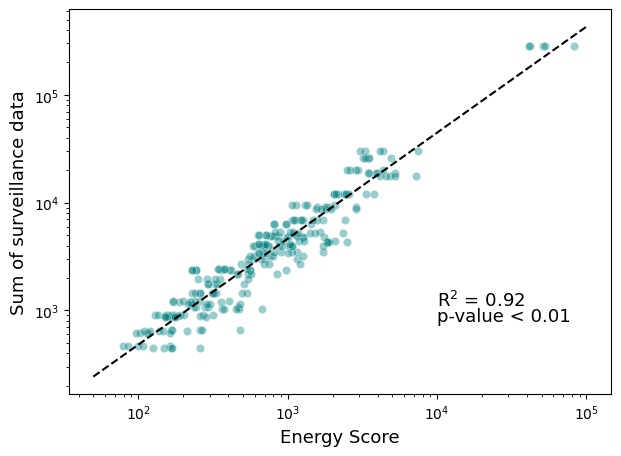

In [76]:
plt.subplots(1,1,figsize=(7,5))

obs_sum = pd.read_pickle('../coviddat/covid_obs_hosp_sum_rd19.pkl').rename(columns={'value':'sum_val'})

energyscoredf = energyscoresdf[(energyscoresdf.Model == 'MOBS_NEU-GLEAM_COVID') ].dropna()
energyscoredfnorm = energyscoresdf_norm[(energyscoresdf_norm.Model =='MOBS_NEU-GLEAM_COVID') ].dropna()

energyscoredf['modelmap'] = energyscoredf['Model'].apply(lambda x: modelmap[x])
energyscoredf = energyscoredf.sort_values(by='modelmap')
energyscoredf = energyscoredf.merge(obs_sum, on=['location']).sort_values(by='modelmap')

energyscoredfnorm['modelmap'] = energyscoredfnorm['Model'].apply(lambda x: modelmap[x])
energyscoredfnorm = energyscoredfnorm.sort_values(by='modelmap')
energyscoredfnorm = energyscoredfnorm.merge(obs_sum, on=['location']).sort_values(by='modelmap')

sns.scatterplot(data=energyscoredf, x='energyscore', y='sum_val', color='teal', alpha=.4)


plt.xlabel('Energy Score', fontsize=13)
plt.ylabel('Sum of surveillance data', fontsize=13)

slope, intercept, r_value, p_value, std_err = linregress(energyscoredf.energyscore, energyscoredf.sum_val,
                                                        alternative='two-sided')
    
logslope, logintercept, logr_value, logp_value, logstd_err = linregress(np.log10(energyscoredf.energyscore), 
                                                                            np.log10(energyscoredf.sum_val),
                                                                           alternative='two-sided')  
    
xval = np.linspace(50, 100000, 100)
yval = 10**(logslope*np.log10(xval)+logintercept)

plt.plot(xval, yval, '--',color='k')


plt.text(10000,1100, r'R$^2$ = '+str(round(r_value**2, 3)), fontsize=13)
plt.text(10000,800, r'p-value < 0.01', fontsize=13)

print(p_value)

#plt.ylim([100, 5e5])

plt.xscale('log')
plt.yscale('log')

plt.savefig('../figs/sumobs_ES_rd19.pdf')

0.13326993316808197


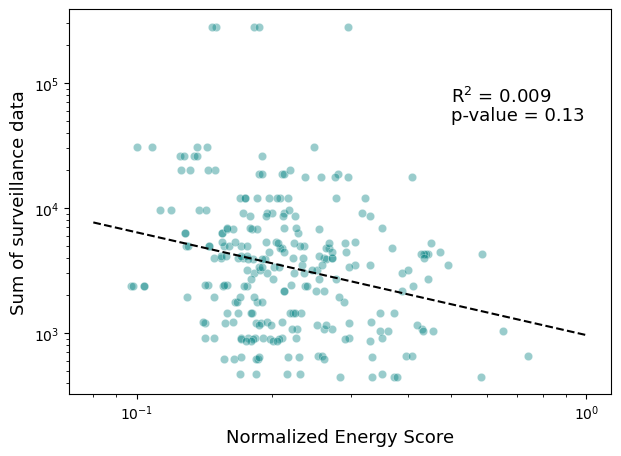

In [77]:
plt.subplots(1,1,figsize=(7,5))

obs_sum = pd.read_pickle('../coviddat/covid_obs_hosp_sum_rd19.pkl').rename(columns={'value':'sum_val'})

energyscoredf = energyscoresdf[(energyscoresdf.Model == 'MOBS_NEU-GLEAM_COVID') ].dropna()
energyscoredfnorm = energyscoresdf_norm[(energyscoresdf_norm.Model =='MOBS_NEU-GLEAM_COVID') ].dropna()

energyscoredf['modelmap'] = energyscoredf['Model'].apply(lambda x: modelmap[x])
energyscoredf = energyscoredf.sort_values(by='modelmap')
energyscoredf = energyscoredf.merge(obs_sum, on=['location']).sort_values(by='modelmap')

energyscoredfnorm['modelmap'] = energyscoredfnorm['Model'].apply(lambda x: modelmap[x])
energyscoredfnorm = energyscoredfnorm.sort_values(by='modelmap')
energyscoredfnorm = energyscoredfnorm.merge(obs_sum, on=['location']).sort_values(by='modelmap')


sns.scatterplot(data=energyscoredfnorm, x='energyscore', y='sum_val', color='teal', alpha=.4)


plt.xlabel('Normalized Energy Score', fontsize=13)
plt.ylabel('Sum of surveillance data', fontsize=13)

slope, intercept, r_value, p_value, std_err = linregress(energyscoredfnorm.energyscore, energyscoredfnorm.sum_val,
                                                        alternative='two-sided')
    
logslope, logintercept, logr_value, logp_value, logstd_err = linregress(np.log10(energyscoredfnorm.energyscore), 
                                                                            np.log10(energyscoredfnorm.sum_val),
                                                                           alternative='two-sided')
    
    
xval = np.linspace(.08, 1, 100)
yval = 10**(logslope*np.log10(xval)+logintercept)

plt.plot(xval, yval, '--',color='k')


plt.text(.5,70000, r'R$^2$ = '+str(round(r_value**2, 3)), fontsize=13)
plt.text(.5,50000, f'p-value = {round(p_value,2)}', fontsize=13)

print(p_value)

#plt.ylim([100, 5e5])

plt.xscale('log')
plt.yscale('log')

plt.savefig('../figs/sumobs_ESnorm_rd19.pdf')

plots comparing energy score and WIS values

In [49]:
models = ['CFA-Scenarios', 'JHU_UNC-flepiMoP', 'MOBS_NEU-GLEAM_COVID', 'PSI-M_CoV_2025',
            'UIUC-IMMCYC', 'UNCC-Hierbin', 'UT-ImmunoSEIRS', 'UVA-adaptive']

modelmap = {'MOBS_NEU-GLEAM_COVID':'Model A', 'CFA-Scenarios':'Model B', 'JHU_UNC-flepiMoP': 'Model C', 
            'PSI-M_CoV_2025':'Model D', 'UIUC-IMMCYC':'Model E', 'UNCC-Hierbin':'Model F', 
            'UT-ImmunoSEIRS':'Model G', 'UVA-adaptive':'Model H'}

6.242844100542e-311


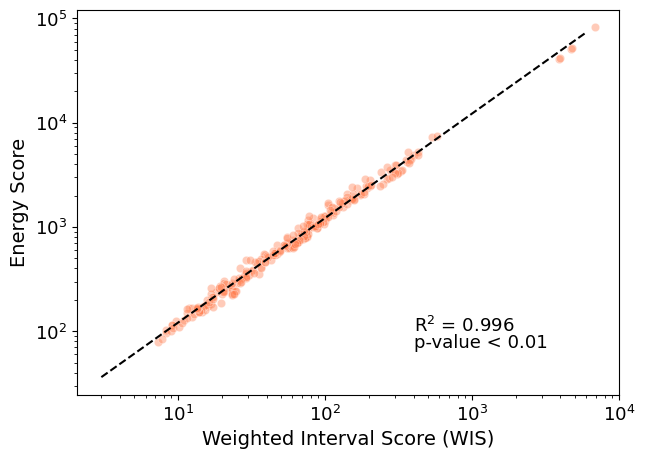

In [82]:
fig, axes = plt.subplots(figsize=(7,5))
rd = 4
es = pd.read_pickle("../coviddat/energyscore_individual_rd19_covidhosp.pkl")
wisdf = pd.read_pickle("../coviddat/wis_trajectory_indiv_covid_rd19_hosp.pkl")

cmap = plt.get_cmap('Set2', 10)
colors = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]

es =es[es.Model=='MOBS_NEU-GLEAM_COVID']
wisdf =  wisdf[wisdf.Model == 'MOBS_NEU-GLEAM_COVID']
    
allscores = es.merge(wisdf, on=['location', 'Label','Model']).dropna()
allscores['modelmap'] = allscores['Model'].apply(lambda x: modelmap[x])
allscores = allscores.sort_values(by='modelmap')

sns.scatterplot(data=allscores, x='WIS', y='energyscore', color='coral', alpha=.4)

slope, intercept, r_value, p_value, std_err = linregress(allscores.WIS, allscores.energyscore,
                                                        alternative='two-sided')

logslope, logintercept, logr_value, logp_value, logstd_err = linregress(np.log10(allscores.WIS), 
                                                                        np.log10(allscores.energyscore),
                                                                       alternative='two-sided')
print(p_value)

xval = np.linspace(3, 6000, 100)
yval = 10**(logslope*np.log10(xval)+logintercept)

plt.plot(xval, yval, '--',color='k')


plt.text(400,100, r'R$^2$ = '+str(round(r_value**2, 3)), fontsize=13)
plt.text(400,70, r'p-value < 0.01', fontsize=13)


plt.xlabel('Weighted Interval Score (WIS)', fontsize=14)
plt.ylabel('Energy Score', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xscale("log")
plt.yscale("log")

plt.savefig('../figs/ESvsWIS_MOBS_rd19.pdf')
plt.show()

In [111]:
p_value

0.0

# Compare SMH projections with baseline model for all models

In [62]:
# download baseline model energy score 

baseline = pd.read_pickle('../coviddat/covid-baseline_energyscore_2526.pkl').rename(columns={'energyscore':'energyscore_baseline',
                                                                           'Model':'baseline_model'})

energyscoresdf = pd.read_pickle("../coviddat/energyscore_individual_rd19_covidhosp.pkl")
energyscoresdf['target'] = 'inc hosp'
energyscoresdf['location'] = energyscoresdf['location'].apply(lambda x: '0'+x if len(x)<2 else x)


# calculate energy score ratio
ES_ratiodf = energyscoresdf.merge(baseline, on = ['location', 'target'])
ES_ratiodf['ES_ratio'] = ES_ratiodf['energyscore'] / ES_ratiodf['energyscore_baseline']

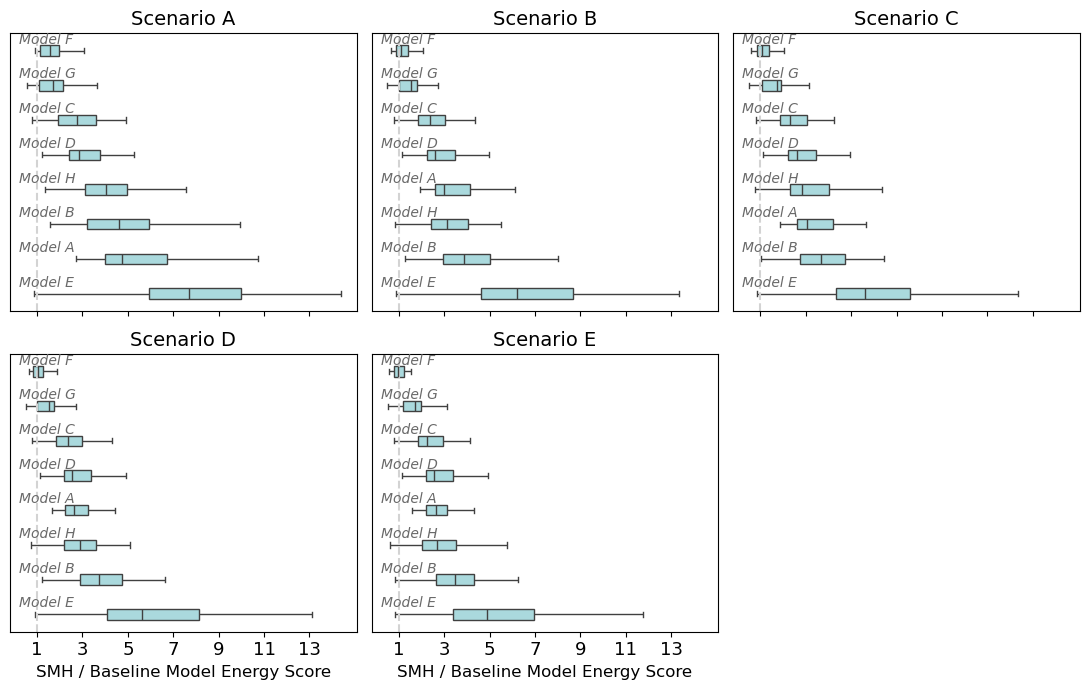

In [69]:
fig, ax = plt.subplots(2,3,figsize=(11,7), sharex=True)
#plt.subplots_adjust(hspace=4)
i=1
for scenario in ES_ratiodf.Label.unique():
    plt.subplot(2,3,i)
    
    if i<4:
        x = 0
    else:
        x=1

        
    if i in [1,4]:
        y=0
    elif i in [2,5]:
        y=1
    else:
        y=2
    
    rankinfo = ES_ratiodf[ES_ratiodf.Label == scenario]
    
    
    my_order = rankinfo.groupby(by=["Model"])["ES_ratio"].median().sort_values(ascending=True).index
    
    g = sns.boxplot(x='ES_ratio', y='Model', data=rankinfo, order = my_order, color = '#17B1BF', width=0.3,
                   showfliers=False)
    
    g.set(yticklabels=[])
    g.set(yticks=[])
        
    if i in [1, 4]:
        plt.ylabel('', fontsize=15)
    else:
        g.set(ylabel=None)    
        
    if i in [3,4,5,6]:
        plt.xlabel('SMH / Baseline Model Energy Score', fontsize=12)
    else:
        g.set(xlabel=None)

    i+=1 
    plt.title(scenario, fontsize=14)
   # plt.xlim([0, 2.5])
    
    
    for patch in ax[x][y].patches:
        r, gr, b, a = patch.get_facecolor()
        patch.set_facecolor((r, gr, b, .4))

    
    plt.axvline(x=1, ymin=0, ymax=3,linestyle='--', color = 'lightgray', alpha=1)

    
    a = 0
    for mod in list(my_order):
        plt.text(0.2,a-.2, modelmap[mod], fontsize=10, style='italic', color='dimgray')
        a+=1
    
    plt.xticks([1,3,5,7,9,11,13],fontsize=13)
    
    
plt.delaxes(ax[1,2])
plt.tight_layout()
#plt.savefig('../figs/ESratio_flurd4_models_h_0530_new.pdf')
plt.show()


In [70]:
ES_ratiodf['Model'] = ES_ratiodf['Model'].apply(lambda x: modelmap[x])

df = ES_ratiodf.groupby(['Label', 'Model']).ES_ratio.describe(percentiles=[.05,.5,.95]).drop(columns=['mean',
                                                         'std']).round(2)

In [71]:
df

count   min    5%   50%    95%    max
Label      Model                                         
Scenario A Model A   52.0  2.71  2.94  4.73   9.13  10.71
           Model B   51.0  1.58  2.26  4.63   8.20   9.92
           Model C   52.0  0.78  1.27  2.75   4.62   9.71
           Model D   52.0  1.20  1.77  2.84   5.18  10.26
           Model E   52.0  0.88  3.10  7.68  12.94  14.39
           Model F   52.0  0.89  0.91  1.57   2.88   4.53
           Model G   51.0  0.54  0.72  1.70   2.83   5.02
           Model H   52.0  1.33  1.64  4.03   7.36   8.73
Scenario B Model A   52.0  1.93  2.00  2.99   5.81   7.33
           Model B   51.0  1.26  1.97  3.88   6.81   9.05
           Model C   52.0  0.78  1.09  2.38   4.11   8.76
           Model D   52.0  1.14  1.63  2.59   4.79   9.64
           Model E   52.0  0.88  2.55  6.19  11.16  13.37
           Model F   52.0  0.66  0.71  1.12   2.20   3.37
           Model G   51.0  0.50  0.65  1.55   2.65   4.37
           Model H   52.0  0.83  1.38  3.11   5.31   7.54
Scenario C Model A   52.0  1.85  1.95  3.04   6.08   7.24
           Model B   51.0  1.02  1.73  3.66   6.39   8.79
           Model C   52.0  0.80  1.14  2.30   3.96   8.72
           Model D   52.0  1.13  1.60  2.60   4.81   9.46
           Model E   52.0  0.85  2.28  5.62  10.17  12.35
           Model F   52.0  0.57  0.68  1.09   2.11   3.25
           Model G   51.0  0.51  0.70  1.71   2.88   4.96
           Model H   52.0  0.76  1.33  2.82   5.29   7.40
Scenario D Model A   52.0  1.64  1.76  2.63   4.42   7.18
           Model B   51.0  1.24  1.84  3.72   6.61   8.77
           Model C   52.0  0.79  1.07  2.36   4.05   8.67
           Model D   52.0  1.14  1.52  2.53   4.71   9.59
           Model E   52.0  0.90  2.26  5.64  10.99  13.10
           Model F   52.0  0.64  0.70  1.05   2.07   3.15
           Model G   51.0  0.53  0.65  1.52   2.51   3.86
           Model H   52.0  0.71  1.20  2.87   4.85   7.20
Scenario E Model A   52.0  1.59  1.67  2.66   4.88   7.07
           Model B   51.0  0.84  1.57  3.46   6.11   8.48
           Model C   52.0  0.80  1.12  2.26   3.87   8.61
           Model D   52.0  1.13  1.57  2.57   4.77   9.37
           Model E   52.0  0.85  2.01  4.88   9.72  11.74
           Model F   52.0  0.56  0.69  0.95   1.96   2.98
           Model G   51.0  0.55  0.65  1.73   3.02   4.93
           Model H   52.0  0.62  1.12  2.67   4.67   7.14

# Rankings

In [88]:
# energy score rank


es_all = pd.read_pickle("../coviddat/energyscore_individual_rd19_covidhosp.pkl")


# standardized rank energy score

dfrankall = pd.DataFrame(columns=['Model', 'location', 'Standard_Rank','target'])

dfa =  es_all.copy()

dfrank = pd.DataFrame(columns=['Model', 'location', 'Standard_Rank', 'target'])

states = list(dfa.location.unique())

for state in states:
    for scenario in dfa.Label.unique():
        filt = dfa[(dfa['location']==state) & (dfa.Label == scenario)]
        filt = filt.sort_values('energyscore')

        rank = list(filt.Model)
        for model in rank:
            rankval = rank.index(model)+1

            new_row = {'Model':model, 'location': state, 'Standard_Rank': rankval, 'target':target,  
                      'Label':scenario}

            dfrank = dfrank.append(new_row, ignore_index=True)

dfrankall = pd.concat([dfrankall, dfrank])
dfrankallenergyscore = dfrankall.reset_index()
dfrankallenergyscore = dfrankallenergyscore.drop(columns=['index']).rename(columns={'Standard_Rank':'standard_rank_ES'})


In [89]:
# wis rank

dfa =  pd.read_pickle("../coviddat/wis_trajectory_indiv_covid_rd19_hosp.pkl")


dfrank = pd.DataFrame(columns=['Model', 'location', 'Standard_Rank', 'target'])

states = list(dfa.location.unique())

for state in states:
    for scenario in dfa.Label.unique():
        filt = dfa[(dfa['location']==state) & (dfa.Label == scenario)]
        filt = filt.sort_values('WIS')

        rank = list(filt.Model)
        for model in rank:
            rankval = rank.index(model)+1

            new_row = {'Model':model, 'location': state, 'Standard_Rank': rankval, 'target':target,  
                      'Label':scenario}

            dfrank = dfrank.append(new_row, ignore_index=True)


dfrankallwis = dfrank.reset_index()
dfrankallwis = dfrankallwis.drop(columns=['index']).rename(columns={'Standard_Rank':'standard_rank_wis'})


In [90]:
dfrankall = dfrankallenergyscore.merge(dfrankallwis, on = ['Model', 'location', 'Label', 'target'])

In [92]:
# calculate kendall tau rank correlation for energy score and WIS
ranks = pd.DataFrame()
for loc in dfrankall.location.unique():
    for scenario in dfrankall.Label.unique():

        df = dfrankall[(dfrankall.location==loc) & (dfrankall.Label==scenario)]
        tau, pval = stats.kendalltau(df.standard_rank_wis, df.standard_rank_ES)
        
        row = pd.DataFrame({'location':loc, 'Label':scenario, 'tau':tau, 'rho':rho}, index=[0])
        
        ranks = pd.concat([ranks, row])

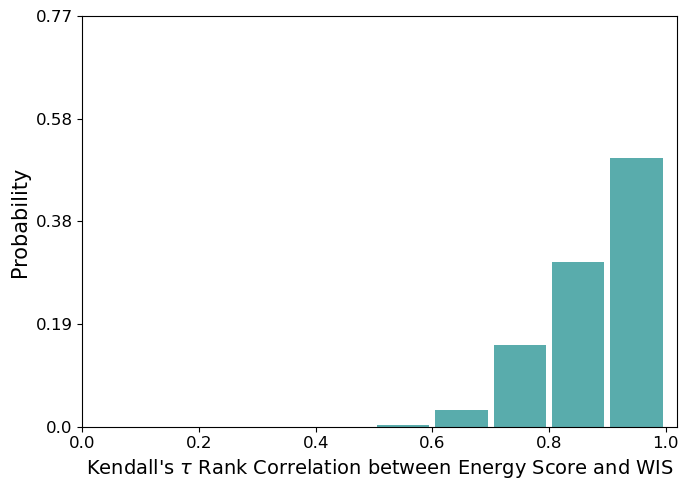

In [102]:
plt.figure(figsize=(7,5))
plt.hist(ranks.tau,bins=5,color='teal', rwidth=.9, alpha=.65, align='mid')
plt.xlabel('Kendall\'s'+ r' $\tau$ Rank Correlation'+ ' between Energy Score and WIS', fontsize=14)
plt.ylabel('Probability', fontsize=15)
plt.xticks([0, .2, .4, .6, .8, 1.0], fontsize=12)
plt.yticks([0,50,100,150,200],fontsize=12, labels = [round(i/len(ranks),2) for i in [0,50,100,150,200]])
#plt.yticklabel([i/len(ranks) for i in [0,50,100,150,200]],fontsize=12)

plt.tight_layout()
#plt.savefig('../figs/kendalltau_histogram_rank_D_updated_0626.pdf')

In [93]:
(len(ranks[ranks.tau>.99])/len(ranks))*100

11.538461538461538

In [33]:
df_filt = dfrankall[(dfrankall.Label=='Scenario B') & (dfrankall.location=='US')]
df_filt['modellabel'] = df_filt['Model'].apply(lambda x: modelmap[x])

df_filt

,Model,location,standard_rank_ES,target,Label,standard_rank_wis,modellabel
1728,UNCC-Hierbin,US,1,hospitalization,Scenario B,1,Model F
1729,UT-ImmunoSEIRS,US,2,hospitalization,Scenario B,2,Model G
1730,JHU_UNC-flepiMoP,US,3,hospitalization,Scenario B,4,Model C
1731,MOBS_NEU-GLEAM_COVID,US,4,hospitalization,Scenario B,3,Model A
1732,UVA-adaptive,US,5,hospitalization,Scenario B,6,Model H
1733,PSI-M_CoV_2025,US,6,hospitalization,Scenario B,5,Model D
1734,CFA-Scenarios,US,7,hospitalization,Scenario B,7,Model B
1735,UIUC-IMMCYC,US,8,hospitalization,Scenario B,8,Model E


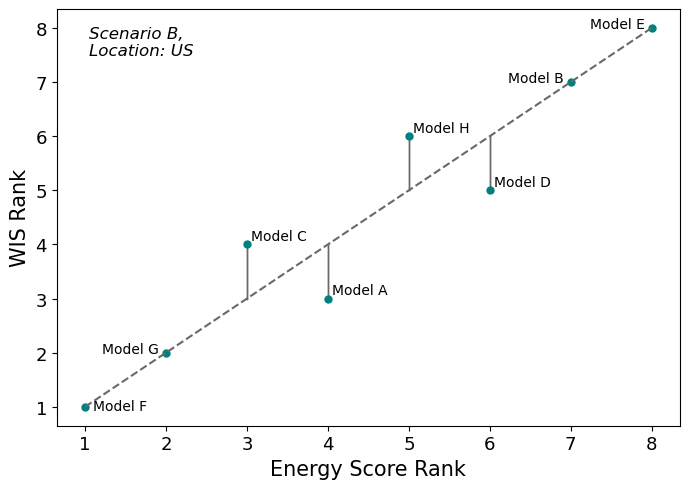

In [39]:
fig,ax = plt.subplots(1,1,figsize=(7,5))

plt.plot(df_filt.standard_rank_ES, df_filt.standard_rank_wis,'.', color='teal', markersize=10)

plt.plot(np.linspace(1,8), np.linspace(1,8),'--', color='dimgray')

for idx, row in df_filt.iterrows():
    if row['modellabel']in ['Model B', 'Model E', 'Model G']:
        ax.annotate(
            row['modellabel'],  # or whatever column has your labels
            (row.standard_rank_ES, row.standard_rank_wis),
            textcoords="offset points",
            xytext=(-5, 0), 
            ha='right', # offset in points from the data point
            fontsize=10
        )
    elif row['modellabel']=='Model F':
        ax.annotate(
            row['modellabel'],  # or whatever column has your labels
            (row.standard_rank_ES, row.standard_rank_wis),
            textcoords="offset points",
            xytext=(6, -2), 
            fontsize=10
        )
    else:
        ax.annotate(
            row['modellabel'],  # or whatever column has your labels
            (row.standard_rank_ES, row.standard_rank_wis),
            textcoords="offset points",
            xytext=(3, 3),        # offset in points from the data point
            fontsize=10
        )
        
    for idx, row in df_filt.iterrows():
        x = row.standard_rank_ES
        y = row.standard_rank_wis
        ax.plot([x, x], [y, x], '-', color='dimgray', linewidth=0.8, zorder=0)


plt.xlabel('Energy Score Rank', fontsize=15)
plt.ylabel('WIS Rank', fontsize=15)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.text(1.05,7.5,'Scenario B, \nLocation: US', fontsize=12, fontstyle='italic')

plt.tight_layout()

plt.savefig('../figs/ESWIS_rankcompare_scatter_B-US_rd19.pdf')


plt.show()

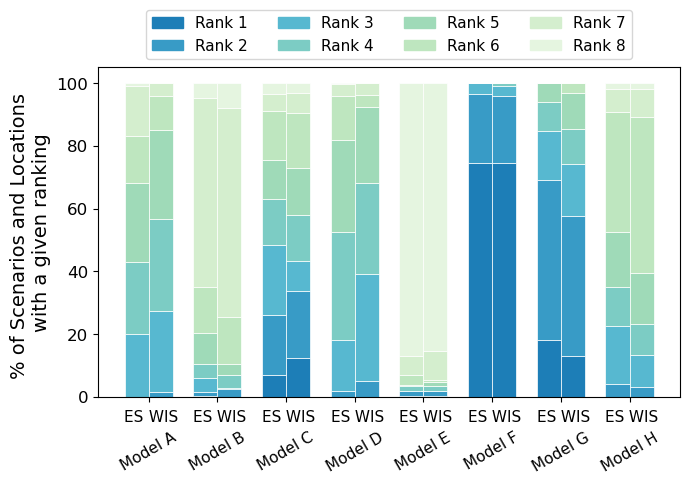

In [79]:
dfrankall['model_name'] = dfrankall['Model'].apply(lambda x: modelmap[x])

es_counts = dfrankall.groupby('model_name')['standard_rank_ES'].value_counts(normalize=True).unstack(fill_value=0) * 100
wis_counts = dfrankall.groupby('model_name')['standard_rank_wis'].value_counts(normalize=True).unstack(fill_value=0) * 100

models = es_counts.index.tolist()
ranks = sorted(set(es_counts.columns) | set(wis_counts.columns))


for r in ranks:
    if r not in es_counts.columns:
        es_counts[r] = 0
    if r not in wis_counts.columns:
        wis_counts[r] = 0
es_counts = es_counts[ranks]
wis_counts = wis_counts[ranks]


x = np.arange(len(models))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

colors = plt.cm.GnBu_r(np.linspace(0.2, 0.9, len(ranks)))


bottom_es = np.zeros(len(models))
bottom_wis = np.zeros(len(models))

for i, rank in enumerate(ranks):
    ax.bar(x - bar_width/2, es_counts[rank].values, bar_width,
           bottom=bottom_es, color=colors[i], edgecolor='white', linewidth=0.5,
           label=f'Rank {rank}' if i == i else '')  # label once
    ax.bar(x + bar_width/2, wis_counts[rank].values, bar_width,
           bottom=bottom_wis, color=colors[i], edgecolor='white', linewidth=0.5)
    bottom_es += es_counts[rank].values
    bottom_wis += wis_counts[rank].values

handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(ranks))]
labels = [f'Rank {r}' for r in ranks]
ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.1), loc='center', 
          ncol=4, frameon=True, fontsize=11)

for xi in x:
    ax.text(xi - bar_width/2, -8, 'ES ', ha='center', fontsize=11)
    ax.text(xi + bar_width/2, -8, ' WIS', ha='center', fontsize=11)


ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='center', fontsize=11)
ax.tick_params(axis='x', pad=20)  

#plt.subplots_adjust(bottom=0.1)  
    
ax.set_ylabel('% of Scenarios and Locations \nwith a given ranking', fontsize=14)
plt.yticks(fontsize=12)
ax.set_ylim(0, 105)
#ax.set_title('Rank Distribution by Model: ES vs WIS', fontsize=14)
plt.tight_layout()


plt.savefig('../figs/ESWIS_rankcompare_bar_rd19.pdf')

plt.show()

# Energy score ratio for all locations

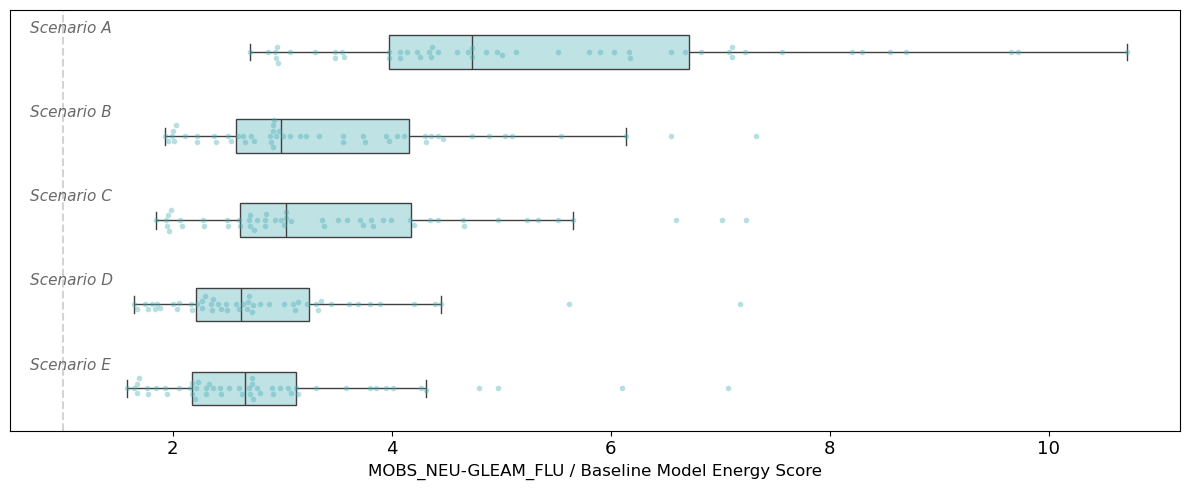

In [80]:
fig, ax = plt.subplots(1,1,figsize=(12,5))
#plt.subplots_adjust(hspace=4)
i=1

baseline = pd.read_pickle('../coviddat/covid-baseline_energyscore_2526.pkl').rename(columns={'energyscore':'energyscore_baseline',
                                                                           'Model':'baseline_model'})

energyscoresdf = pd.read_pickle("../coviddat/energyscore_individual_rd19_covidhosp.pkl")
energyscoresdf['target'] = 'inc hosp'
energyscoresdf['location'] = energyscoresdf['location'].apply(lambda x: '0'+x if len(x)<2 else x)

# calculate energy score ratio
ES_ratiodf = energyscoresdf.merge(baseline, on = ['location', 'target'])
ES_ratiodf['ES_ratio'] = ES_ratiodf['energyscore'] / ES_ratiodf['energyscore_baseline']    
rankinfo = ES_ratiodf[(ES_ratiodf.Model == 'MOBS_NEU-GLEAM_COVID')]


my_order = rankinfo.Label.unique()

g = sns.boxplot(x='ES_ratio', y='Label', data=rankinfo,order=my_order, color = '#17B1BF', width=0.4,
               showfliers=False)

for patch in ax.patches:
    r, gr, b, a = patch.get_facecolor()
    patch.set_facecolor((r, gr, b, .3))
    
# plot underlying distribution
sns.swarmplot(x='ES_ratio', y='Label', data=rankinfo,order=my_order,color = "#49AFB7",alpha = .4,size=4,
              orient="h")  

g.set(yticklabels=[])
g.set(yticks=[])

plt.ylabel('', fontsize=15)
plt.xlabel('MOBS_NEU-GLEAM_FLU / Baseline Model Energy Score', fontsize=12)

i+=1 
#plt.title(scenario, fontsize=14)
#plt.xlim([0, 13])




plt.axvline(x=1, ymin=0, ymax=3,linestyle='--', color = 'lightgray', alpha=1)


mobs_multitarget = pd.read_csv('../coviddat/multitarget_mobs_ratio_median_rd19.csv')

#sns.scatterplot(x='ES_ratio',y='Label',data=mobs_multitarget,color='red',s=250,marker='*',
 #               label='Median Multi-dimensional \nEnergy Score across \nlocations')

#plt.legend(fontsize=13)

a = 0
for mod in list(my_order):
    plt.text(0.7,a-.225, mod, fontsize=11, style='italic', color='dimgray')
    a+=1

plt.xticks(fontsize=13)
plt.tight_layout()

plt.savefig('../figs/MOBS_ESdist_rd19.pdf')
plt.show()
